In [3]:
import numpy as np
from numpy.linalg import eigvals
from energyflow import EFP
from energyflow import EFPSet
from energyflow.utils import gen_massless_phase_space
import matplotlib.pyplot as plt

In [4]:
NEvents=10000
uniform_N5 = gen_massless_phase_space(NEvents,5,energy=1.0)
uniform_N10 = gen_massless_phase_space(NEvents,10,energy=1.0)
uniform_N20 = gen_massless_phase_space(NEvents,20,energy=1.0)
uniform_N50 = gen_massless_phase_space(NEvents,50,energy=1.0)
uniform_N100 = gen_massless_phase_space(NEvents,100,energy=1.0)

Two versions of the EFP with two vertices and two lines, $\sum_{i,j} z_i z_j \theta_{ij}^2$

In [8]:
efp_graph = [(0,1), (0,1)]
EFP_Patrick = EFP(efp_graph, measure='ee', beta=2, normed=False, coords='epxpypz')

def _compute_z_theta(events):
    """Energy fractions and pairwise angular weights with this notebook's conventions.

    For each event computes::

        z_i        = 2 E_i / sum_k E_k
        theta_{ij} = (1 - cos theta_{ij}) / 2

    where ``cos theta_{ij}`` is the cosine of the 3D angle between particles i and j
    (computed from the spatial momenta). Self-angles ``theta_{ii}`` are exactly zero.

    Parameters
    ----------
    events : ndarray, shape (NEvents, N, 4) or (N, 4)
        Particles in (E, px, py, pz) coordinates.

    Returns
    -------
    z : ndarray, shape (NEvents, N)
    theta : ndarray, shape (NEvents, N, N)
    """
    events = np.asarray(events, dtype=float)
    if events.ndim == 2:
        events = events[None]
    E  = events[..., 0]
    p3 = events[..., 1:4]
    z = 2.0 * E / E.sum(axis=-1, keepdims=True)
    pmag = np.linalg.norm(p3, axis=-1)
    pdot = np.einsum('...ia,...ja->...ij', p3, p3)
    denom = pmag[..., :, None] * pmag[..., None, :]
    cos_th = np.divide(pdot, denom, out=np.zeros_like(pdot), where=denom > 0)
    diag = np.arange(events.shape[1])
    cos_th[:,diag,diag]=1.0 #ensure self-angles are exactly zero
    return z, 0.5 * (1.0 - cos_th)


def my_efp(events):
    """

    Computed directly from the definition::

        EFP_m = sum_{i, j} z_i z_j theta_{ij}^2

    Returns
    -------
    out : ndarray, shape (NEvents, m_max - 1)
        out[..., k] is the EFP value for m = k + 2.
    """
    z, th = _compute_z_theta(events)
    zz = z[..., :, None] * z[..., None, :]
    Ap = th * th
    return (zz * Ap).sum(axis=(-2, -1))

#check that these return the same value on one event with our definition of zs and thetas

zs10, thetas10 = _compute_z_theta(uniform_N10)
print(EFP_Patrick.compute(zs=zs10[0],thetas=thetas10[0]))
print(EFP_Patrick.compute(uniform_N10[0])/(2**2)) #accounting from the powers of 2 in our definition of the angular measure
print(my_efp(uniform_N10[0]).flatten()[-1])

1.4083180126393084
1.4083180126393082
1.4083180126393084


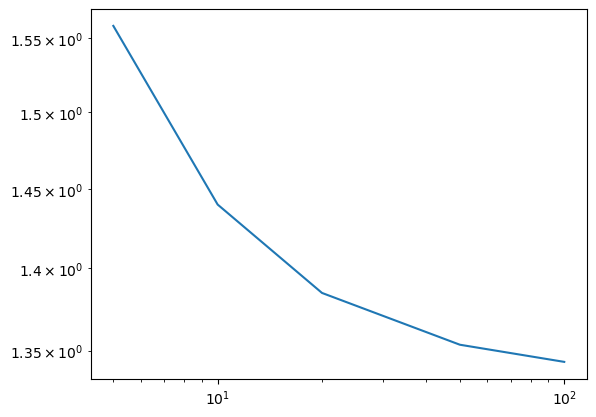

In [12]:
EFPmean_N5 = np.mean(my_efp(uniform_N5))
EFPmean_N10 = np.mean(my_efp(uniform_N10))
EFPmean_N20 = np.mean(my_efp(uniform_N20))
EFPmean_N50 = np.mean(my_efp(uniform_N50))
EFPmean_N100 = np.mean(my_efp(uniform_N100))
plt.plot([5,10,20,50,100],[EFPmean_N5,EFPmean_N10,EFPmean_N20,EFPmean_N50,EFPmean_N100])
plt.xscale('log')
plt.yscale('log')

In [14]:
print(np.mean(my_efp(uniform_N5)**2) - (np.mean(my_efp(uniform_N5))**2))
print(np.mean(my_efp(uniform_N10)**2) - (np.mean(my_efp(uniform_N10))**2))
print(np.mean(my_efp(uniform_N20)**2) - (np.mean(my_efp(uniform_N20))**2))
print(np.mean(my_efp(uniform_N50)**2) - (np.mean(my_efp(uniform_N50))**2))
print(np.mean(my_efp(uniform_N100)**2) - (np.mean(my_efp(uniform_N100))**2))

0.011980711691040202
0.003543292090355976
0.0009078403101252519
0.00016194774775080134
3.843690425142654e-05
